In [24]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score

from tensorflow import keras
from tensorflow.keras import layers
le = LabelEncoder()


In [2]:
# Reproducible seed
SEED = 8675309

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
%cd

C:\Users\Andrew


In [31]:
# File paths
path_data = Path("Documents/GitHub/DAGE_Andrew/data_clean")

# Load apprehension dataset
survey = pd.read_csv(path_data/"survey_apprehension.csv")
display(survey.head())

,q_advice_text,biggest_fear
0,dont do things you dont want to do,solo_apprehension
1,just remember that they are probably just as n...,group_apprehension
2,just be yourself no one can blame you for bein...,group_apprehension
3,dont overthink the conversation the person you...,group_apprehension
4,i would tell my friend that its completely nor...,solo_apprehension


In [32]:
# Extract out "Equal" observations
survey_equals = survey[survey['biggest_fear'] == 'equal'].copy()
survey = survey[apprehension['biggest_fear'] != 'no_dominant_mode'].copy()

# Create splits on non-equal observations
survey_train, survey_temp = train_test_split(
    survey,
    test_size=0.30,
    stratify=survey["biggest_fear"],
    random_state=SEED
)
survey_val, survey_test = train_test_split(
    survey_temp,
    test_size=0.50,
    stratify=survey_temp["biggest_fear"],
    random_state=SEED
)

# Remove temp object
del survey_temp

In [40]:
# Separate inputs/outputs
x_train = survey_train["q_advice_text"].astype(str)
x_val = survey_val["q_advice_text"].astype(str)
X_test = survey_test["q_advice_text"].astype(str)


y_train = le.fit_transform(survey_train["biggest_fear"])
y_val = le.transform(survey_val["biggest_fear"])
y_test = le.transform(survey_test["biggest_fear"])

print(f'Classes: {le.classes_}')

Classes: ['equal' 'group_apprehension' 'solo_apprehension']


In [34]:
# Parameters for vectorization
max_tokens = 10000
sequence_length = 100

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length,
)

In [41]:
# Adapt vectorizer to training text
vectorizer.adapt(x_train['q_advice_text'].values)

KeyError: 'q_advice_text'

In [28]:
# Parameters for vectorization
max_tokens = 10000
sequence_length = 100

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length,
)

# Adapt vectorizer to training text
vectorizer.adapt(x_train['q_advice_text'].values)

# Transform the data
x_train = vectorizer(x_train['q_advice_text'].values)
x_val = vectorizer(x_val['q_advice_text'].values)
x_test = vectorizer(x_test['q_advice_text'].values)

KeyError: 'q_advice_text'

In [19]:





# =============================================================================
# Function to Build and Train Neural Network
# =============================================================================

def build_model():
    model = keras.Sequential([
        layers.Input(shape=(1,), dtype=tf.string),

        vectorizer,

        layers.Embedding(
            input_dim=max_tokens,
            output_dim=64
        ),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(0.20),

        # Corrected: Use sigmoid for binary classification
        layers.Dense(
            len(label_encoder.classes_),
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="Adam",
        loss="sparse_categorical_crossentropy",
        metrics=["f1_score"]
    )

    return model

arch = build_model()

In [22]:
results = []
trained_models = {}

epochs = 20 # Define a reasonable number of epochs
batch_size = 32 # Define a reasonable batch size

model = arch.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val)
    )

ValueError: Invalid dtype: object

In [10]:
# =============================================================================
# Train and Evaluate Models (Missing in original code)
# =============================================================================

results = []
trained_models = {}

epochs = 20 # Define a reasonable number of epochs
batch_size = 32 # Define a reasonable batch size

model = build_model(
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val)
    )

    # Evaluate on validation data to get metrics
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

    # Predict on validation data to calculate F1 score
    val_probabilities = model.predict(X_val, verbose=0)
    val_predictions = np.argmax(val_probabilities, axis=1)
    val_f1 = f1_score(y_val, val_predictions)

    results.append({
        "optimizer": name,
        "validation_accuracy": val_accuracy,
        "validation_f1": val_f1,
        "validation_loss": val_loss
    })
    trained_models[name] = {'model': model, 'history': history} # Store model and history

results_df = pd.DataFrame(results)


# Final test with best-performing optimizer.

# Corrected: Sort results_df and select the best optimizer name
best_optimizer_name = results_df.sort_values(
    "validation_f1", ascending=False
).iloc[0]["optimizer"]

# Corrected: Access the best model and its history using its name
best_model = trained_models[best_optimizer_name]['model']
best_history = trained_models[best_optimizer_name]['history']

test_probabilities = best_model.predict(
    X_test,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

print("\nFINAL TEST PERFORMANCE")
print("Optimizer:", best_optimizer_name)
print("Accuracy:", round(test_accuracy, 3))
print("Macro F1:", round(test_macro_f1, 3))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# =============================================================================
# Visualizations
# =============================================================================

import matplotlib.pyplot as plt

plot_df = results_df.sort_values(
    "validation_f1"
)

plt.figure(figsize=(7, 4))

plt.barh(
    plot_df["optimizer"],
    plot_df["validation_macro_f1"]
)

plt.xlabel("Validation Macro-F1")
plt.ylabel("Optimizer")
plt.title("Validation Performance by Optimizer")

plt.tight_layout()
plt.show()

plt.tight_layout()

plt.savefig(
    "/content/DAGE/memos/optimizer_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'y_train_text' is not defined

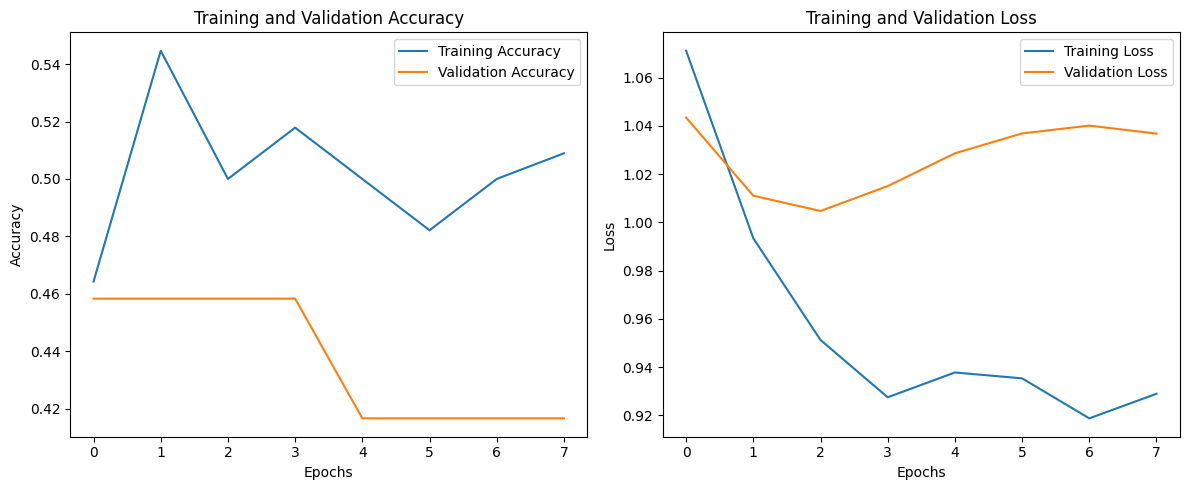

In [ ]:
history_dict = best_history.history

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['F1'], label='Training f1')
plt.plot(history_dict['val_f1'], label='Validation f1')
plt.title('Training and Validation f1')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()